# Lab 04 — Model Selection with Cross-Validation

**Goal:** pick the regularization strength $\lambda$ for Ridge and Lasso using K-fold CV; report final test performance once.

Pair with `docs/03_regression.md` Part B.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42

## 2. Load California Housing + carve test set

In [2]:
df = fetch_california_housing(as_frame=True).frame
X = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
scaler = StandardScaler().fit(X_trainval)
X_trainval_s = scaler.transform(X_trainval)
X_test_s     = scaler.transform(X_test)
print('trainval:', X_trainval_s.shape, '  test:', X_test_s.shape)

trainval: (16512, 8)   test: (4128, 8)


## 3. Manual α-sweep with K-fold CV

Sweep $\alpha$ on a log grid and pick the value that minimizes CV RMSE.

In [3]:
alphas = np.logspace(-4, 2, 25)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

ridge_rmses, lasso_rmses = [], []
for a in alphas:
    ridge_scores = -cross_val_score(Ridge(alpha=a), X_trainval_s, y_trainval,
                                    cv=kf, scoring='neg_mean_squared_error')
    lasso_scores = -cross_val_score(Lasso(alpha=a, max_iter=20000), X_trainval_s, y_trainval,
                                    cv=kf, scoring='neg_mean_squared_error')
    ridge_rmses.append(np.sqrt(ridge_scores).mean())
    lasso_rmses.append(np.sqrt(lasso_scores).mean())

best_ridge_alpha = alphas[int(np.argmin(ridge_rmses))]
best_lasso_alpha = alphas[int(np.argmin(lasso_rmses))]
print(f'best Ridge alpha (manual CV) = {best_ridge_alpha:.4g}')
print(f'best Lasso alpha (manual CV) = {best_lasso_alpha:.4g}')

best Ridge alpha (manual CV) = 3.162
best Lasso alpha (manual CV) = 0.0005623


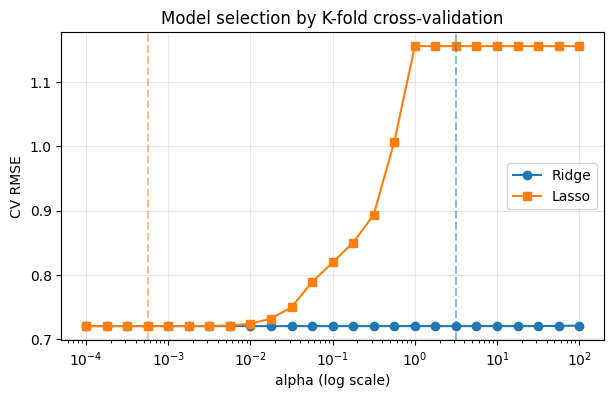

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(alphas, ridge_rmses, marker='o', label='Ridge')
ax.semilogx(alphas, lasso_rmses, marker='s', label='Lasso')
ax.axvline(best_ridge_alpha, color='tab:blue',  ls='--', alpha=0.5)
ax.axvline(best_lasso_alpha, color='tab:orange', ls='--', alpha=0.5)
ax.set_xlabel('alpha (log scale)'); ax.set_ylabel('CV RMSE')
ax.set_title('Model selection by K-fold cross-validation')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 4. Sklearn's built-in CV classes

`RidgeCV` and `LassoCV` do the same sweep internally — useful when you don't need a custom report.

In [5]:
ridge_cv = RidgeCV(alphas=alphas, cv=kf).fit(X_trainval_s, y_trainval)
lasso_cv = LassoCV(alphas=alphas, cv=kf, max_iter=20000, random_state=SEED).fit(X_trainval_s, y_trainval)
print(f'RidgeCV picked alpha = {ridge_cv.alpha_:.4g}')
print(f'LassoCV picked alpha = {lasso_cv.alpha_:.4g}')

RidgeCV picked alpha = 3.162
LassoCV picked alpha = 0.0005623


## 5. Final test-set evaluation — touch the test set once

In [6]:
def report(name, model):
    pred = model.predict(X_test_s)
    return {
        'model': name,
        'test_RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
        'test_MAE':  float(mean_absolute_error(y_test, pred)),
        'test_R2':   float(r2_score(y_test, pred)),
    }

lr = LinearRegression().fit(X_trainval_s, y_trainval)
rows = [report('LinearRegression',                lr),
        report(f'Ridge (alpha={ridge_cv.alpha_:.3g})', ridge_cv),
        report(f'Lasso (alpha={lasso_cv.alpha_:.3g})', lasso_cv)]
pd.DataFrame(rows).set_index('model').round(4)

,test_RMSE,test_MAE,test_R2
model,,,
LinearRegression,0.7456,0.5332,0.5758
Ridge (alpha=3.16),0.7455,0.5332,0.5759
Lasso (alpha=0.000562),0.7450,0.5332,0.5764


On California Housing, Ridge and plain LinearRegression score about the same — the dataset is large and there's little overfitting headroom. Lasso may be slightly worse if its $\alpha$ choice zeroed out informative weights. The pattern flips on smaller datasets, which is what the polynomial-fit notebook (`chapter_05_overfitting_regularization.ipynb`) demonstrated.

## 6. Summary

- K-fold CV on the training set is the safe way to pick a hyperparameter; the test set stays untouched.
- `RidgeCV` and `LassoCV` are convenience wrappers that do this in one line.
- Report **mean ± std** of CV scores when available — a single number hides variance across folds.
- Bigger datasets = less to gain from regularization; the polynomial-fit case study shows the opposite limit.